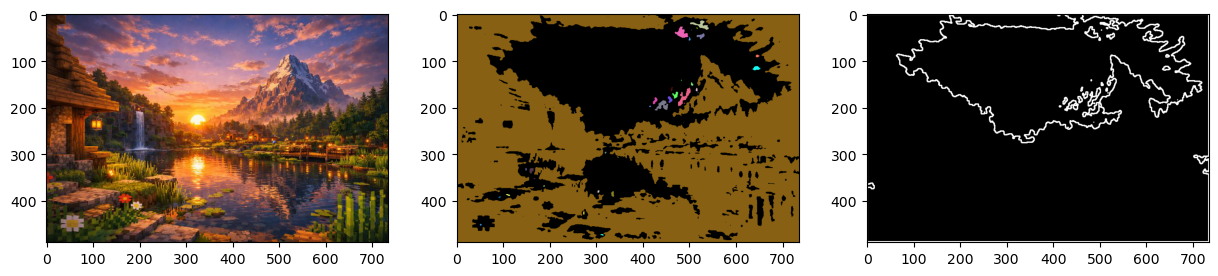

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('paisaje.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# combino tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# encontramos las regiones
num_l, label = cv2.connectedComponents(binary)

# identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

# encontrar fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

plt.subplot(132)
plt.imshow(colorear)

plt.subplot(133)
plt.imshow(contorno_fin, cmap='gray')

plt.show()

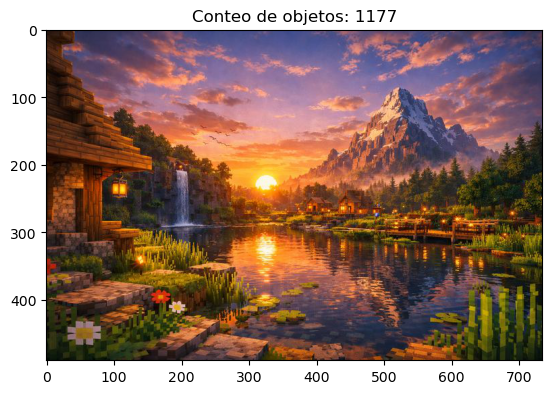

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img= measure.label(binary, connectivity=2)
    num_obj=np.max(e_img)
    return num_obj

img = cv2.imread('paisaje.jpg')
conteo=contar_elementos(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Conteo de objetos: {conteo}')
plt.show()

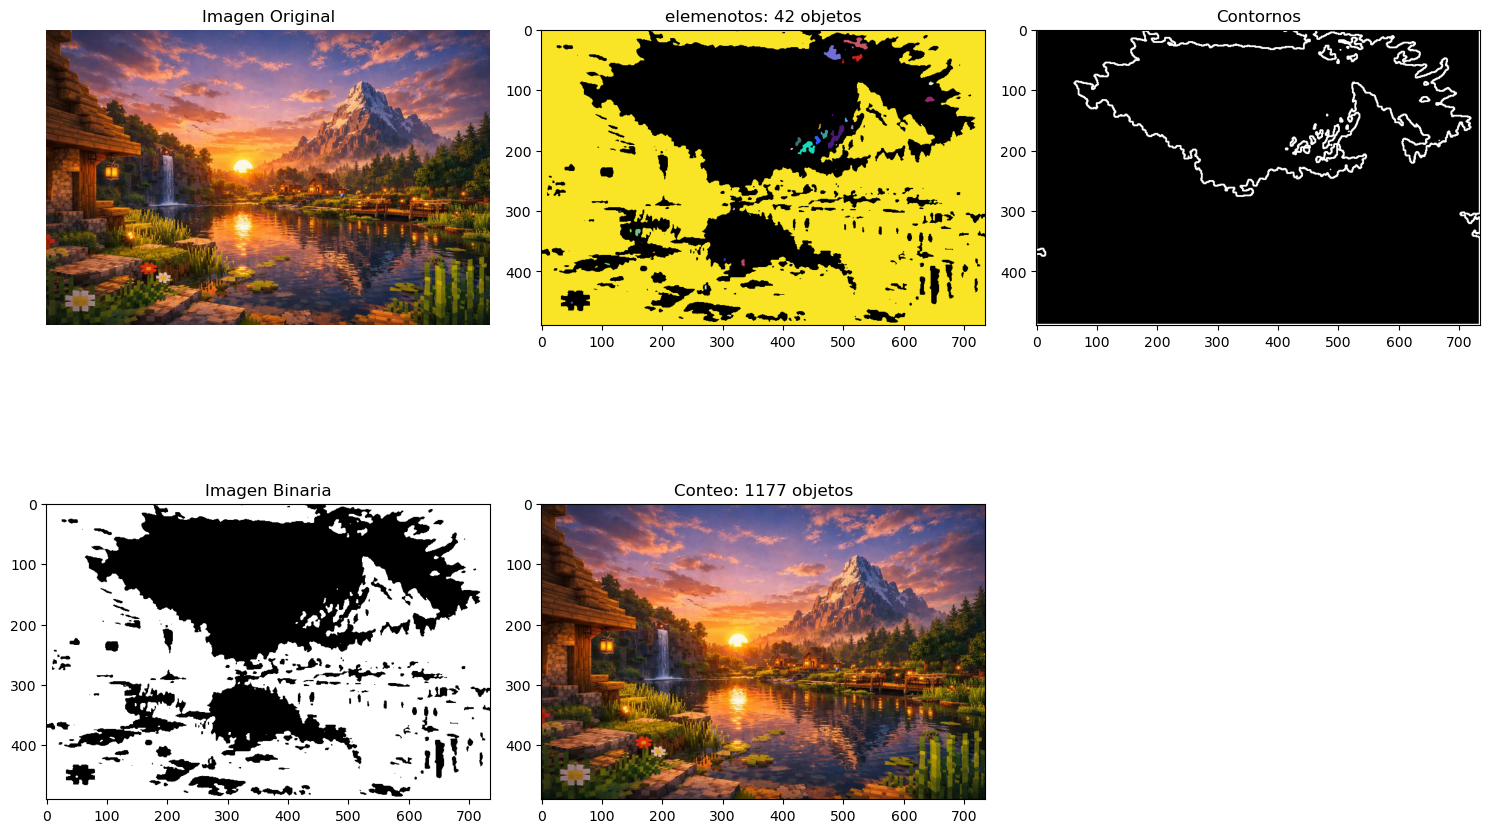

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

# Código 1: connectedComponents
img = cv2.imread('paisaje.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# combino tecnicas
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# encontramos las regiones
num_l, label = cv2.connectedComponents(binary)

# identificamos por colores
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# fondo negro
color[0] = [0, 0, 0]
colorear = color[label]

# encontrar fronteras
contornos, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

# Código 2: measure.label
def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img= measure.label(binary, connectivity=2)
    num_obj=np.max(e_img)
    return num_obj, e_img

conteo, e_img = contar_elementos(img)

# Mostrar resultados combinados
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(colorear)
plt.title(f'elemenotos: {num_l-1} objetos')


plt.subplot(2, 3, 3)
plt.imshow(contorno_fin, cmap='gray')
plt.title('Contornos')


plt.subplot(2, 3, 4)
plt.imshow(binary, cmap='gray')
plt.title('Imagen Binaria')


plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f'Conteo: {conteo} objetos')


plt.tight_layout()
plt.show()